In [41]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add parent directory to sys.path
sys.path.append(parent_dir)

print(parent_dir)


/home/adam/Documents/dev/gradual-aacbr/examples



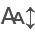

In [42]:
import torch
import torch.optim as optim
from itables import init_notebook_mode, show
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import importlib
from ray import tune

import deeparguing.gradual_aacbr as gradual_aacbr
import deeparguing.semantics.relu_semantics as rs
import deeparguing.base_scores.learned_base_score as lbs
import deeparguing.casebase_edge_weights.learned_partial_order as lpo
import deeparguing.irrelevance_edge_weights.regular_irrelevance as ri
import deeparguing.feature_extractor.feature_weighted_extractor as fwe
import deeparguing.casebase_edge_weights.compute_partial_order as cpo

from deeparguing.train import static_train_model, evaluate_model, cluster_data
from deeparguing.tune import tune_model, objective
from deeparguing.regulariser import sparsity_regulariser, community_preservation_regulariser, connectivity_regulariser, feature_smoothness_regulariser, regularise

from helper import load_glioma, split_data, normalise_input



init_notebook_mode(all_interactive=True)

In [43]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(rs)
    importlib.reload(lbs)
    importlib.reload(lpo)
    importlib.reload(ri)
    importlib.reload(fwe)
    importlib.reload(cpo)

reload_imports()

In [44]:
SEED = 42

## Data Set

In [45]:
X, y = load_glioma()
show(X)
show(y)

In [46]:
all_y = np.unique(y, axis=0)
show(all_y)

## Train Model

### Split into Training, Validation and Test

In [47]:
train_full, train, val, test = split_data(X, y, SEED)

print(f"Test Size:  {len(test['X'])}")
print(f"Train Size:  {len(train['X'])}")
print(f"Validation Size:  {len(val['X'])}")

Test Size:  168
Train Size:  536
Validation Size:  135


### Cluster dataset

In [48]:
GROUP_PROPORTION = 0.25 
X_centroids, y_centroids = cluster_data(train["X"], train["y"], lambda group_size: 20)

20 clusters for [0. 1.]
20 clusters for [1. 0.]


In [49]:
show(X_centroids)

In [50]:
X_centroids = torch.tensor(X_centroids, dtype=torch.float32)
y_centroids = torch.tensor(y_centroids, dtype=torch.float32)

### Convert to Torch

In [51]:
X_train_full, y_train_full = torch.tensor(train_full["X"]), torch.tensor(train_full["y"], dtype=torch.float32)
X_train, y_train = torch.tensor(train["X"]), torch.tensor(train["y"], dtype=torch.float32)
X_val, y_val = torch.tensor(val["X"]), torch.tensor(val["y"], dtype=torch.float32)
X_test, y_test = torch.tensor(test["X"]), torch.tensor(test["y"], dtype=torch.float32)

### Normalize dataset

In [52]:
train_mean = X_train.mean(dim=0)
train_std = X_train.std(dim=0)

X_train = normalise_input(X_train, train_mean, train_std)
X_centroids = normalise_input(X_centroids, train_mean, train_std)
X_val = normalise_input(X_val, train_mean, train_std)
X_test = normalise_input(X_test, train_mean, train_std)



In [53]:
show(X_train.cpu().numpy())

### Train Model

In [54]:
DEFAULT_CASE = X_train.mean(axis=0)

X_DEFAULTS = DEFAULT_CASE.tile(len(all_y), 1)
Y_DEFAULTS = torch.tensor(all_y)


In [55]:
MAX_ITERS = 20
EPOCHS = 3000
USE_SYMMETRIC_ATTACKS = False
LR = 0.027724410326258685
MOMENTUM = 0.9
TEMPERATURE = 1.6522458359237715
USE_BLOCKERS = False
# want it to work regardless of this?
TORCH_SEED = 78741





In [56]:
reload_imports()
torch.manual_seed(TORCH_SEED) # TRY DIFFERENT INITIAL WEIGHTS 

no_features = X_train.shape[-1]
semantics = rs.ReluSemantics(max_iters=MAX_ITERS, epsilon=0)
po_fe = fwe.FeatureWeightedExtractor(no_features)
bs_fe = fwe.FeatureWeightedExtractor(no_features)
comp_func = cpo.Subtractor(temperature=TEMPERATURE, activation=torch.sigmoid)

partial_order = lpo.LearnedPartialOrder([po_fe], comparison_func=comp_func)
irrelevance = ri.RegularIrrelevance(partial_order)

base_score = lbs.LearnedBaseScore([bs_fe], activation=torch.sigmoid)


alpha = 5 * 1e-4


regulariser = lambda model: regularise(model, [
    [sparsity_regulariser, alpha], 
    [connectivity_regulariser, alpha], 
    [community_preservation_regulariser, alpha],
    [feature_smoothness_regulariser, alpha]
    ])

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

Accuracy, Precision, Recall, F1
(0.6962962962962963, np.float64(0.34814814814814815), np.float64(0.5), np.float64(0.4104803493449782))


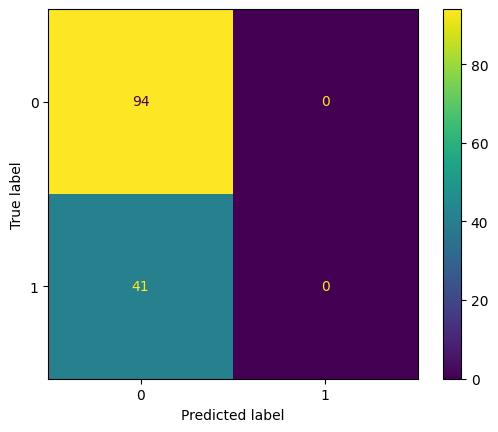

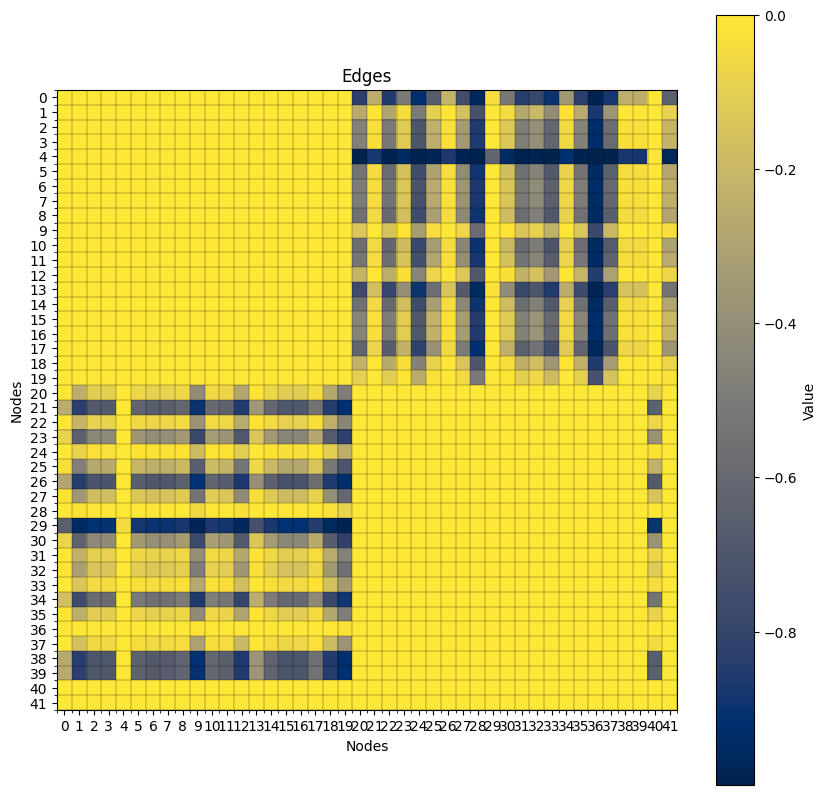

(0.6962962962962963,
 np.float64(0.34814814814814815),
 np.float64(0.5),
 np.float64(0.4104803493449782))

In [57]:
reload_imports()
evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=True, print_graph = False )
# model.plot_casebase_edge_weights_parameters()
# model.plot_base_score_parameters()

Epoch 3000, Loss: 1.231143: 100%|██████████| 3000/3000 [00:29<00:00, 102.95it/s]


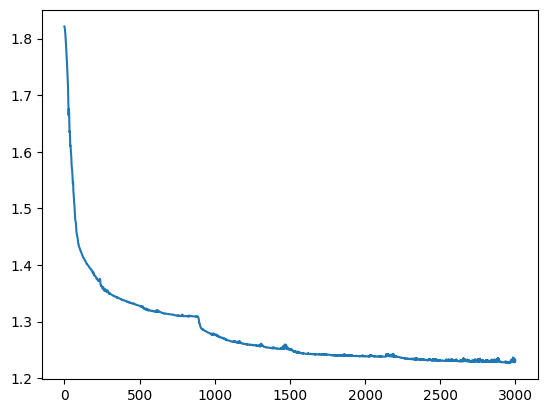

In [58]:
static_train_model(model, X_centroids, y_centroids, 
                   X_DEFAULTS, Y_DEFAULTS, optimizer, 
                   criterion, EPOCHS, X_new_cases=X_train, y_new_cases=y_train, 
                   use_symmetric_attacks=False, use_blockers=USE_BLOCKERS, 
                   plot_loss_curve=True,
                   regularise_graph=regulariser
                   )

Accuracy, Precision, Recall, F1
(0.8074074074074075, np.float64(0.7912051395657953), np.float64(0.8410742086144266), np.float64(0.7951680672268908))


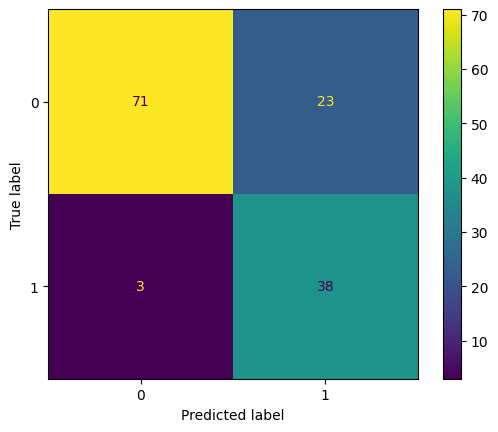

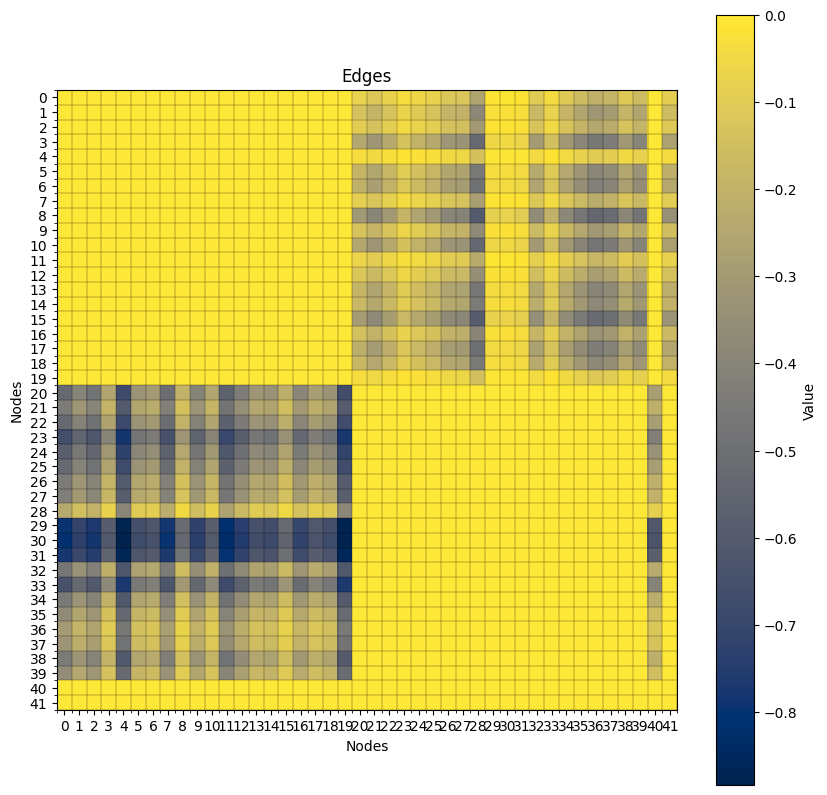

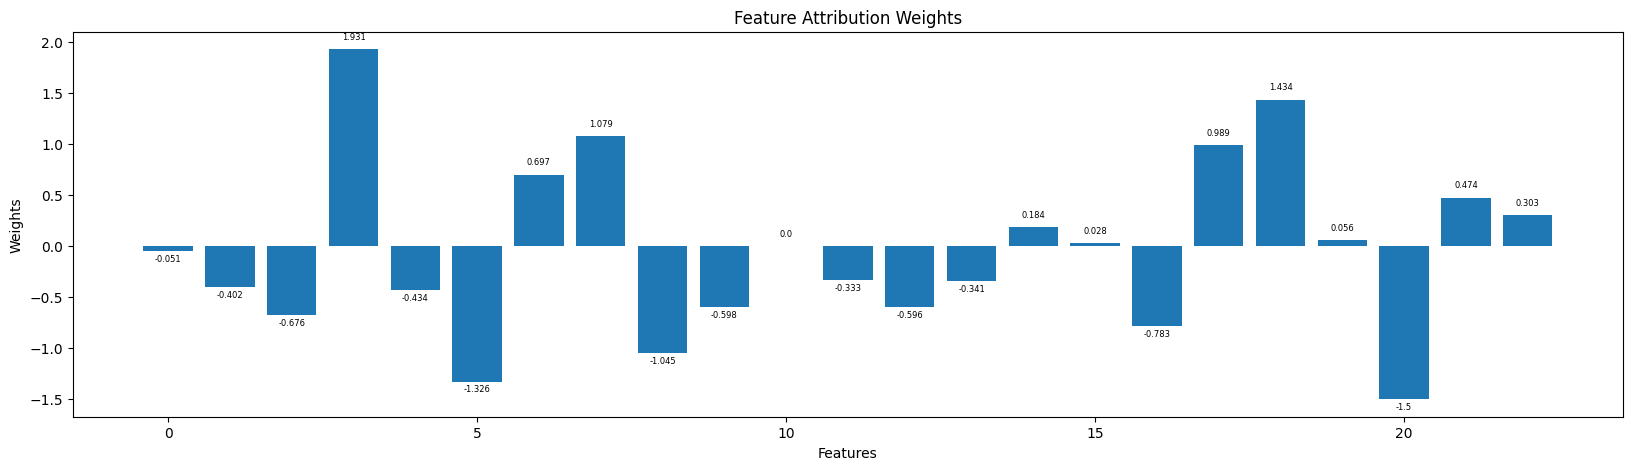

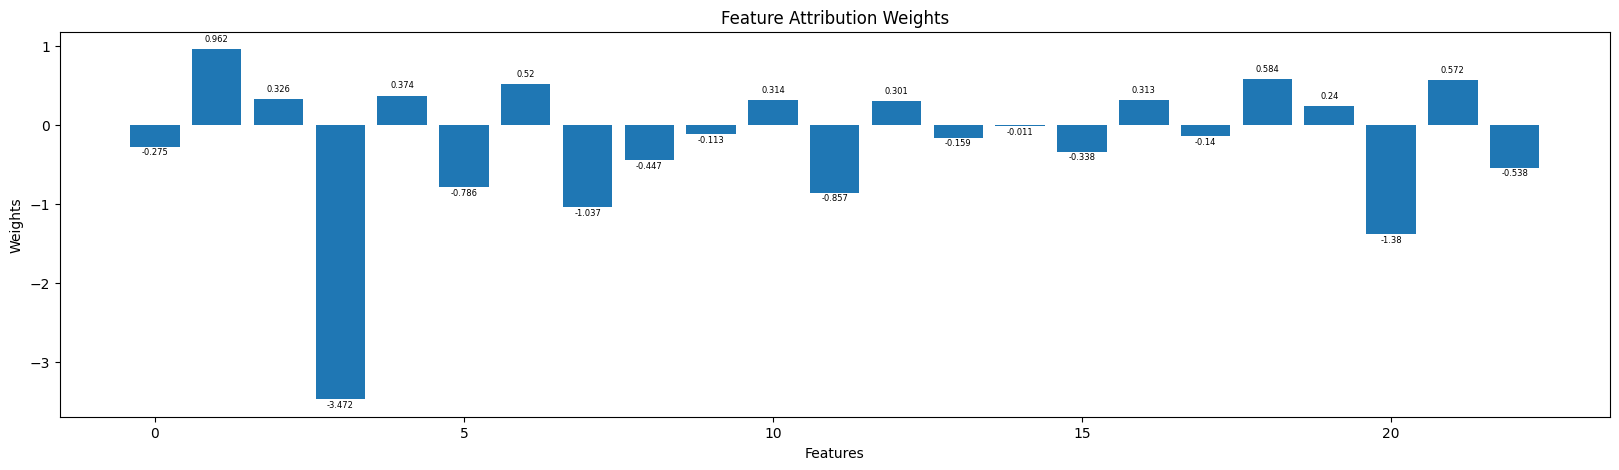

In [59]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=False, print_graph=False  )

model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [60]:
assert(False)

AssertionError: 

Accuracy, Precision, Recall, F1
(0.7, np.float64(0.5166666666666667), np.float64(0.6666666666666666), np.float64(0.5698924731182796))


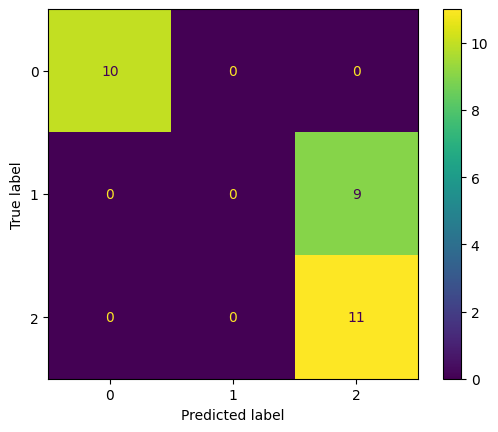

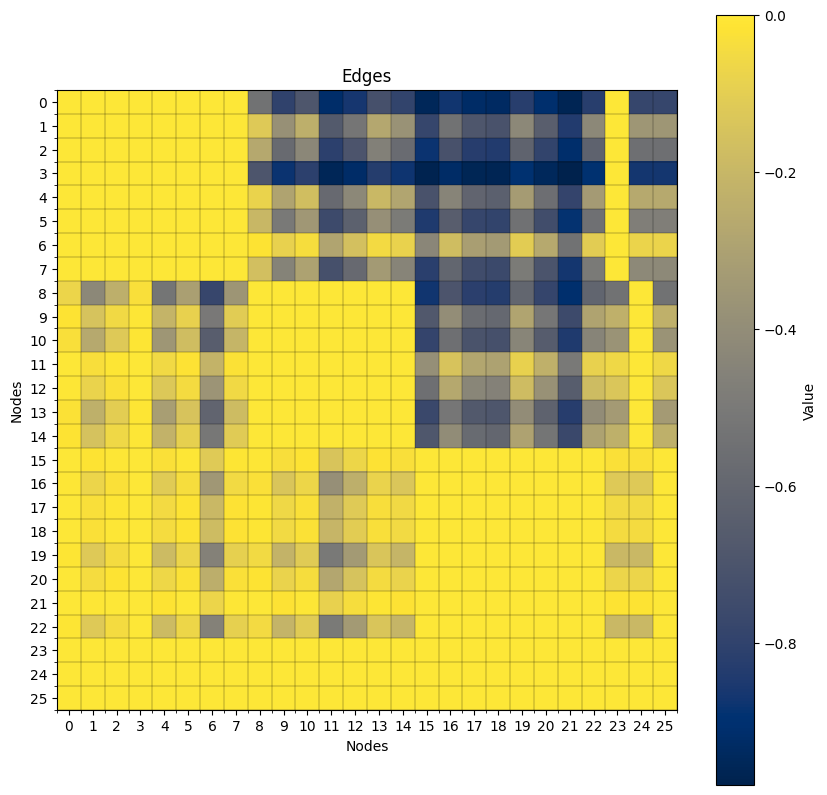

(0.7,
 np.float64(0.5166666666666667),
 np.float64(0.6666666666666666),
 np.float64(0.5698924731182796))

In [ ]:

evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_test, y_test, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=True, print_graph = False )